# 8: Plotting

In [4]:
import alpaca
from alpaca.plotting.mpl import exclusionplot, alp_channels_plot
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 20, 'text.usetex': True, 'font.family': 'serif', 'font.serif': 'Computer Modern Roman'})

## Branching ratios and partial decay widths

In [20]:
#Create grid of ma, fa and couplings
ma = np.logspace(-2, np.log10(4), 30)
fa = 10000
coupling = alpaca.ALPcouplings({'cuR': np.diag([0,0,1])},
    4*np.pi*fa, 'derivative_above').match_run(4, 'VA_below')
brs = alpaca.alp_channels_branching_ratios(ma, coupling, fa, integrator='no_rge')
dws = alpaca.alp_channels_decay_widths(ma, coupling, fa, integrator='no_rge')

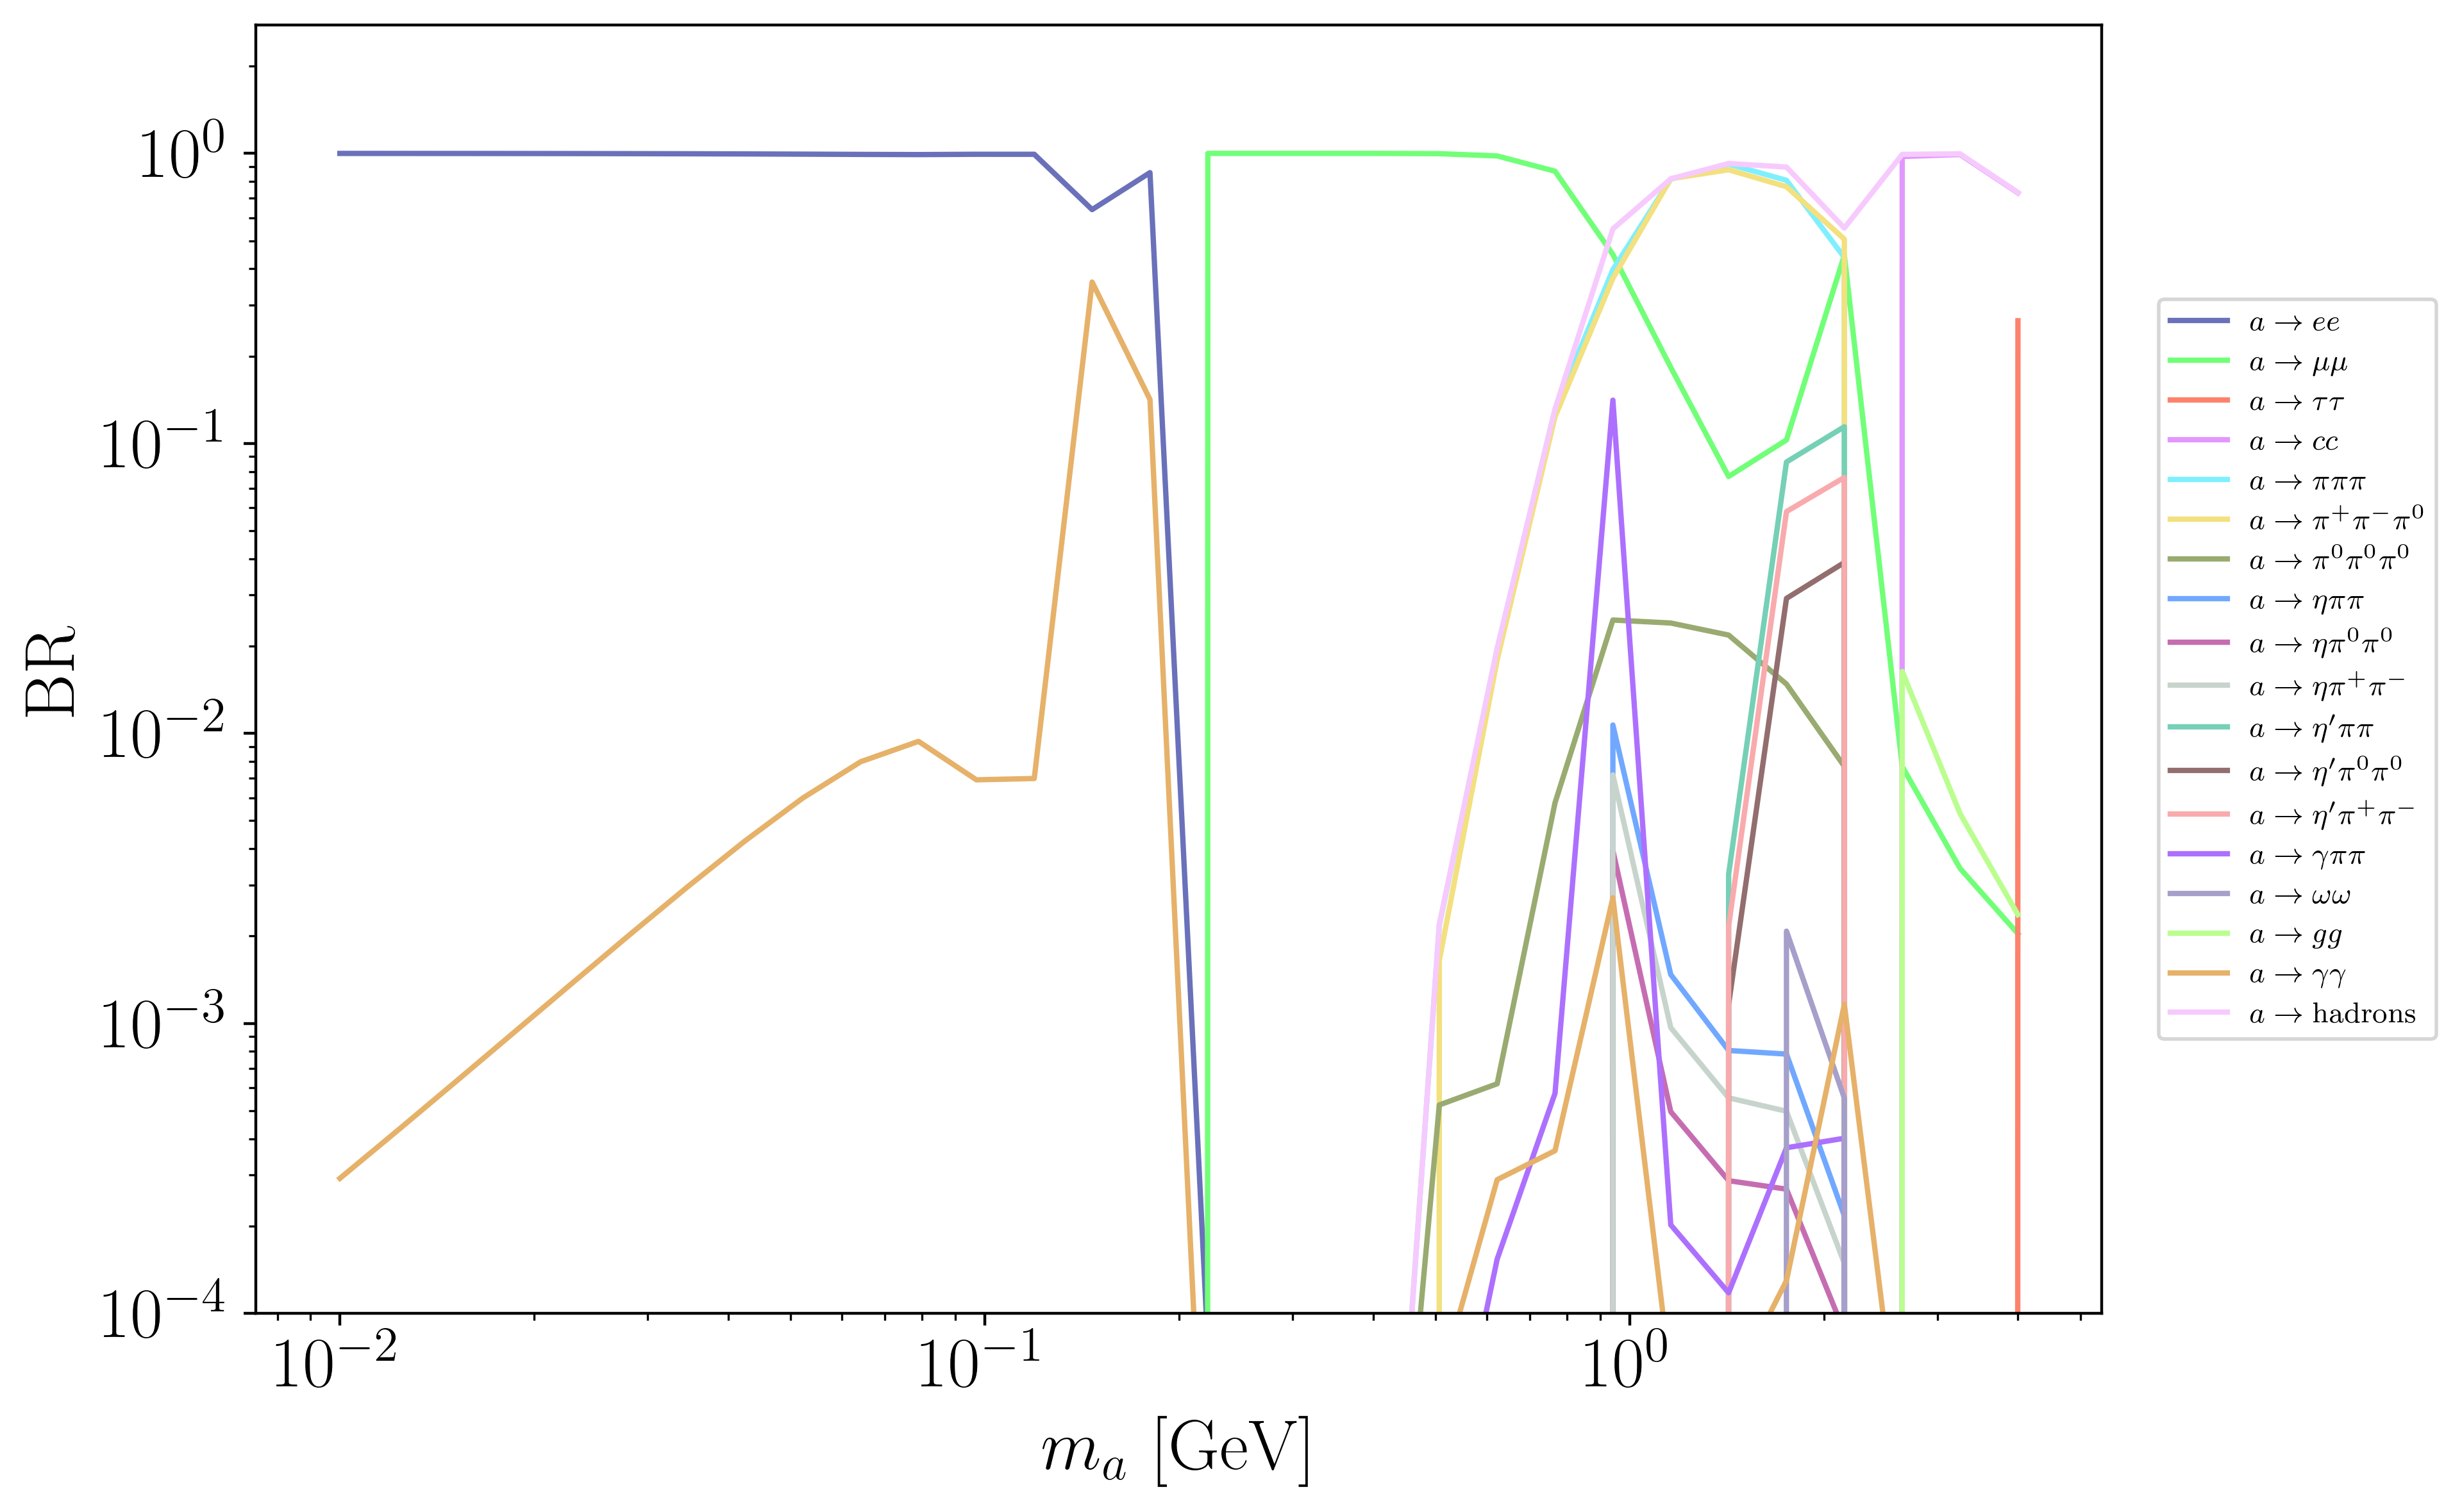

In [ ]:
fig = plt.figure(figsize=(25.4/2.54, 16/2.54),\
dpi=400)
ax = fig.gca()
ax = alp_channels_plot(ma, brs, r'$m_a$ [GeV]', r'BR', 1e-4, ax=ax)
legend = ax.get_legend()

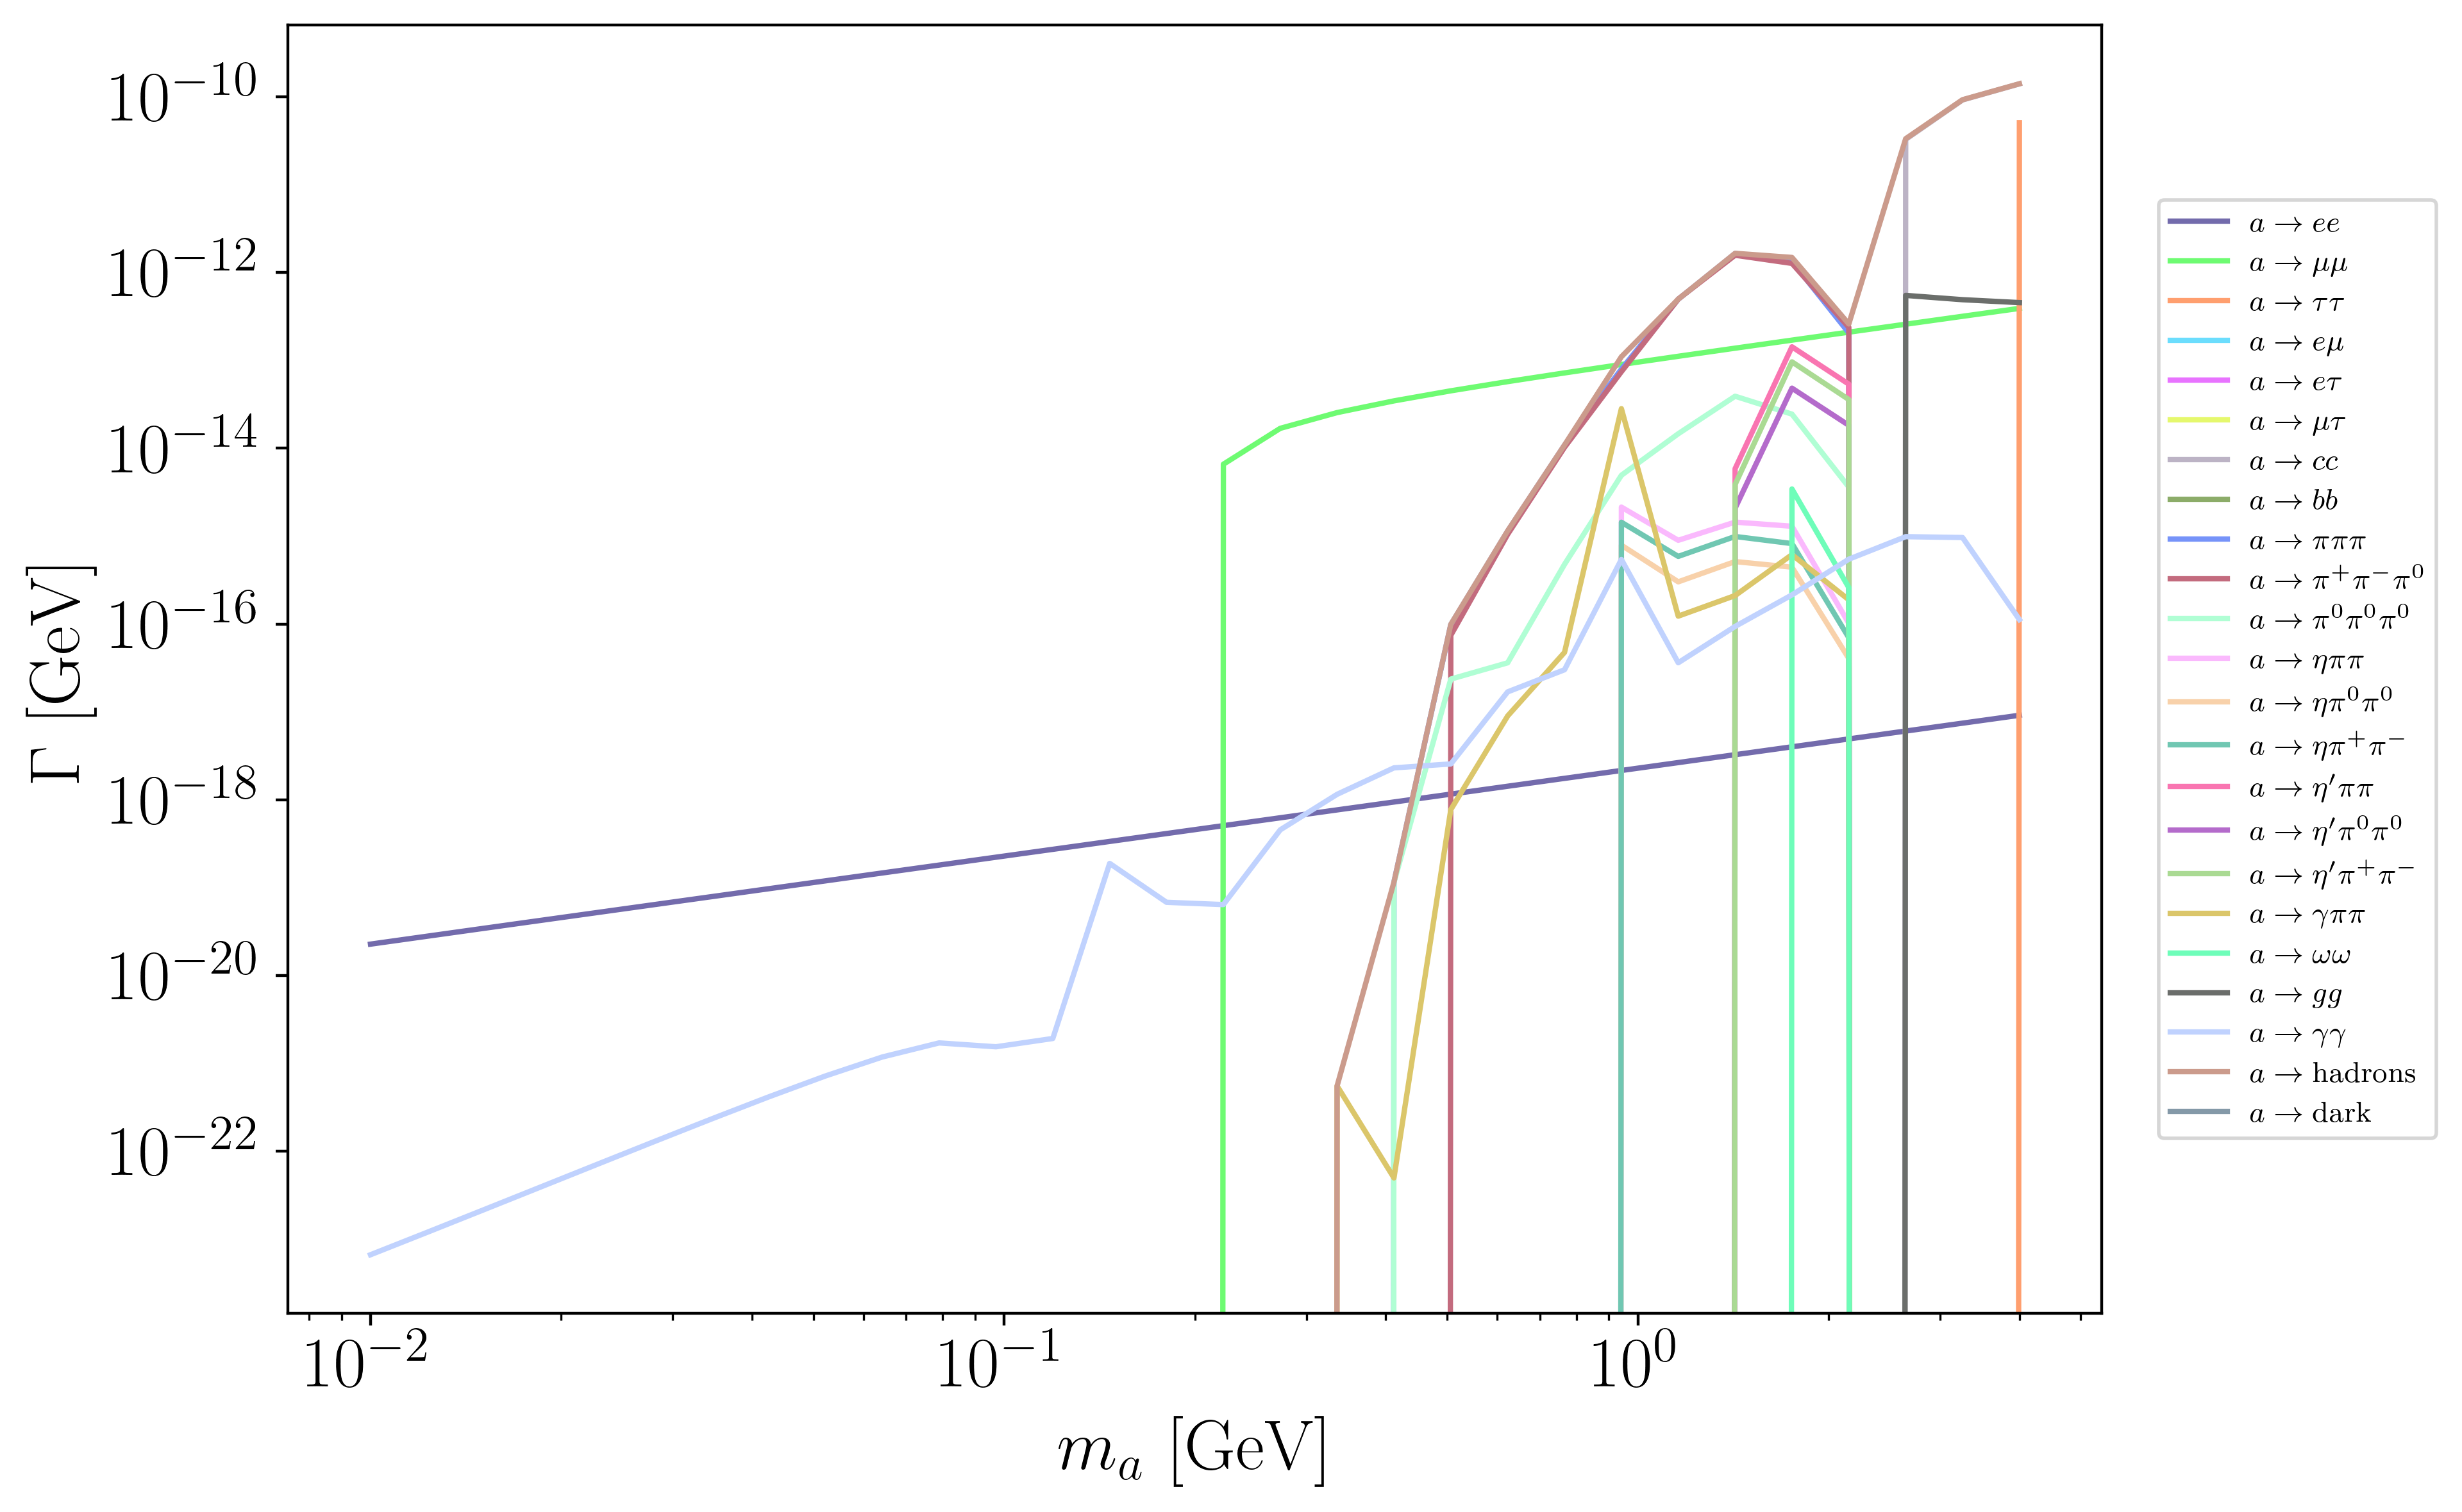

In [23]:
fig = plt.figure(figsize=(25.4/2.54, 16/2.54),\
dpi=400)
ax = fig.gca()
ax = alp_channels_plot(ma, dws, r'$m_a$ [GeV]', r'$\Gamma$ [GeV]', ax=ax)
legend = ax.get_legend()

## Exclusion plots

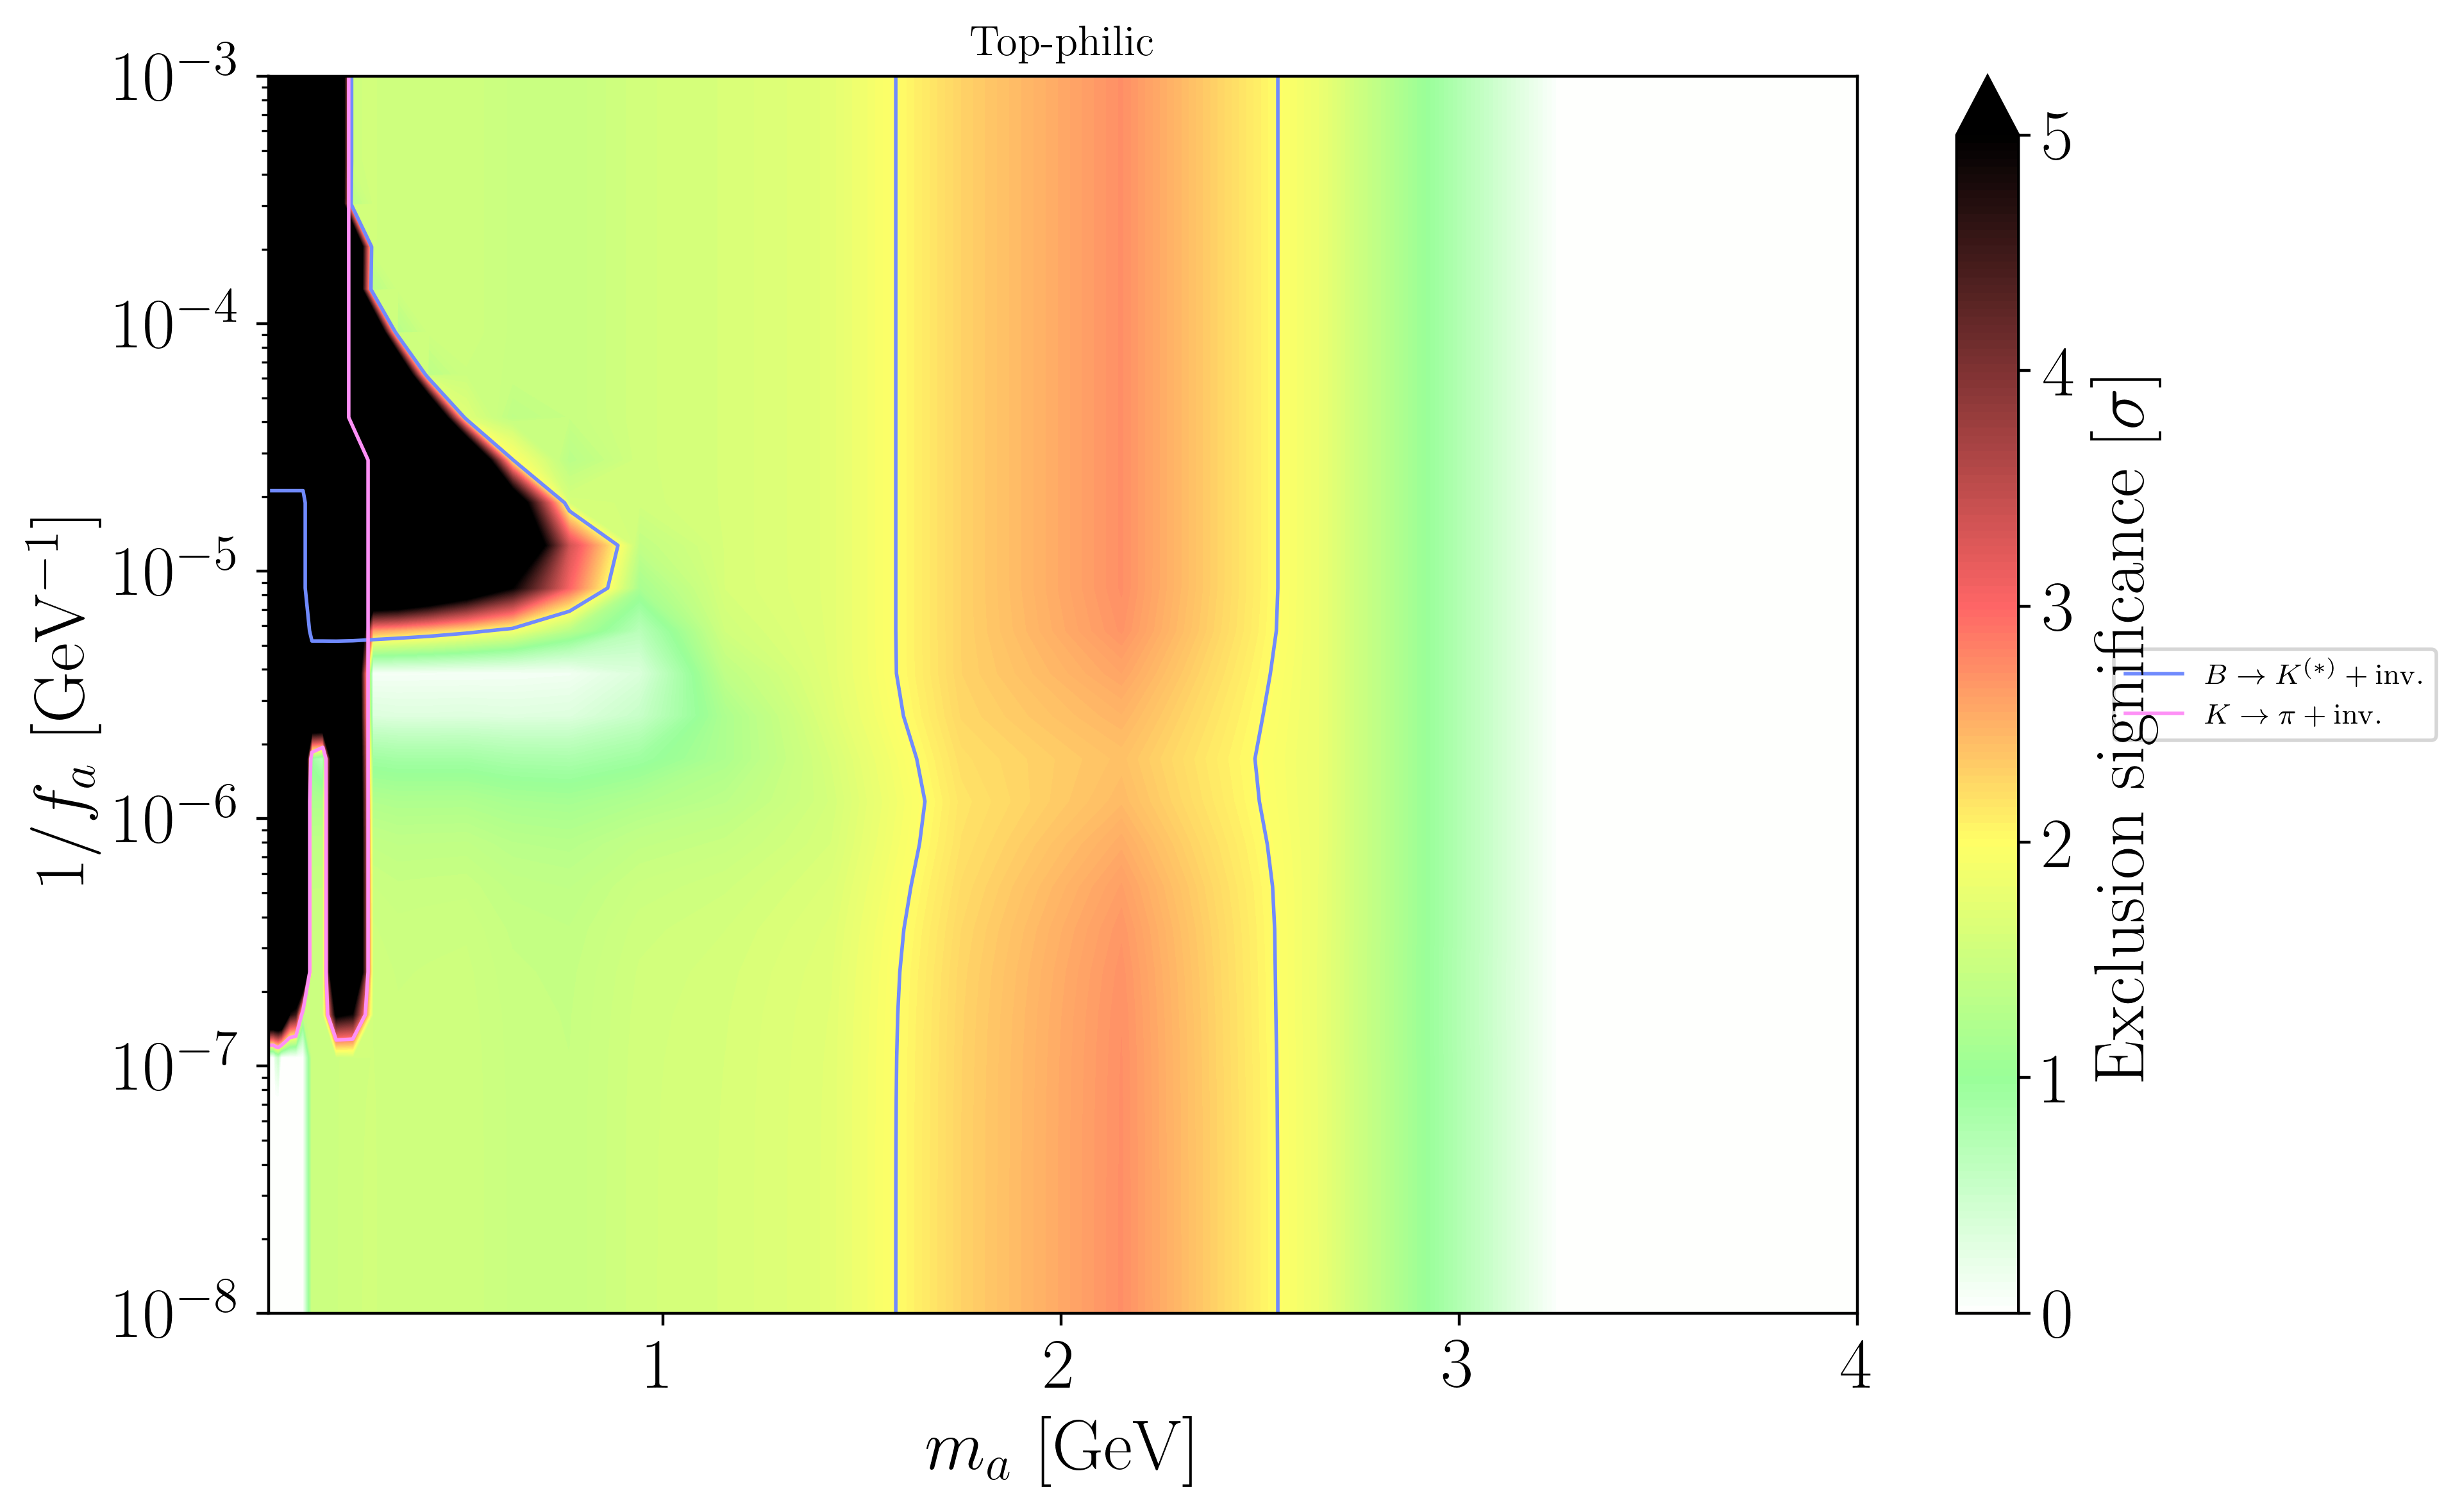

In [ ]:
#Create grid of ma, fa and couplings
ma = np.logspace(-2, np.log10(4), 30)
fa = np.logspace(3, 8, 30)
x_ma, y_fa = np.meshgrid(ma, fa)
couplings = [alpaca.ALPcouplings({'cuR': np.diag([0,0,1])},
    4*np.pi*f, 'derivative_above').match_run(4, 'VA_below') for f in fa]
x_ma, y_couplings = np.meshgrid(ma, couplings)

transitions = [
    alpaca.sectors.default_sectors['BKinv'],
    alpaca.sectors.default_sectors['Kpiinv']
]

chi2 = alpaca.statistics.get_chi2(
    transitions,
    x_ma,
    y_couplings,
    y_fa,
    integrator='no_rge'   # The running below 4 GeV is negligible
)
fig = plt.figure(figsize=(25.4/2.54, 16/2.54),\
dpi=400)
ax = fig.gca()
ax = exclusionplot(
    x_ma, 1/y_fa, chi2,
    r'$m_a$ [GeV]', r'$1/f_a$ [GeV$^{-1}$]', r'Top-philic',
    ax=ax
)
ax.set_xscale('linear')
fig.savefig('08_results/plot_BK_Kpi.pdf', bbox_inches='tight')

The following code shows additional customizations: subplots, adding more lines, removing colorbar and legend, and moving legend.

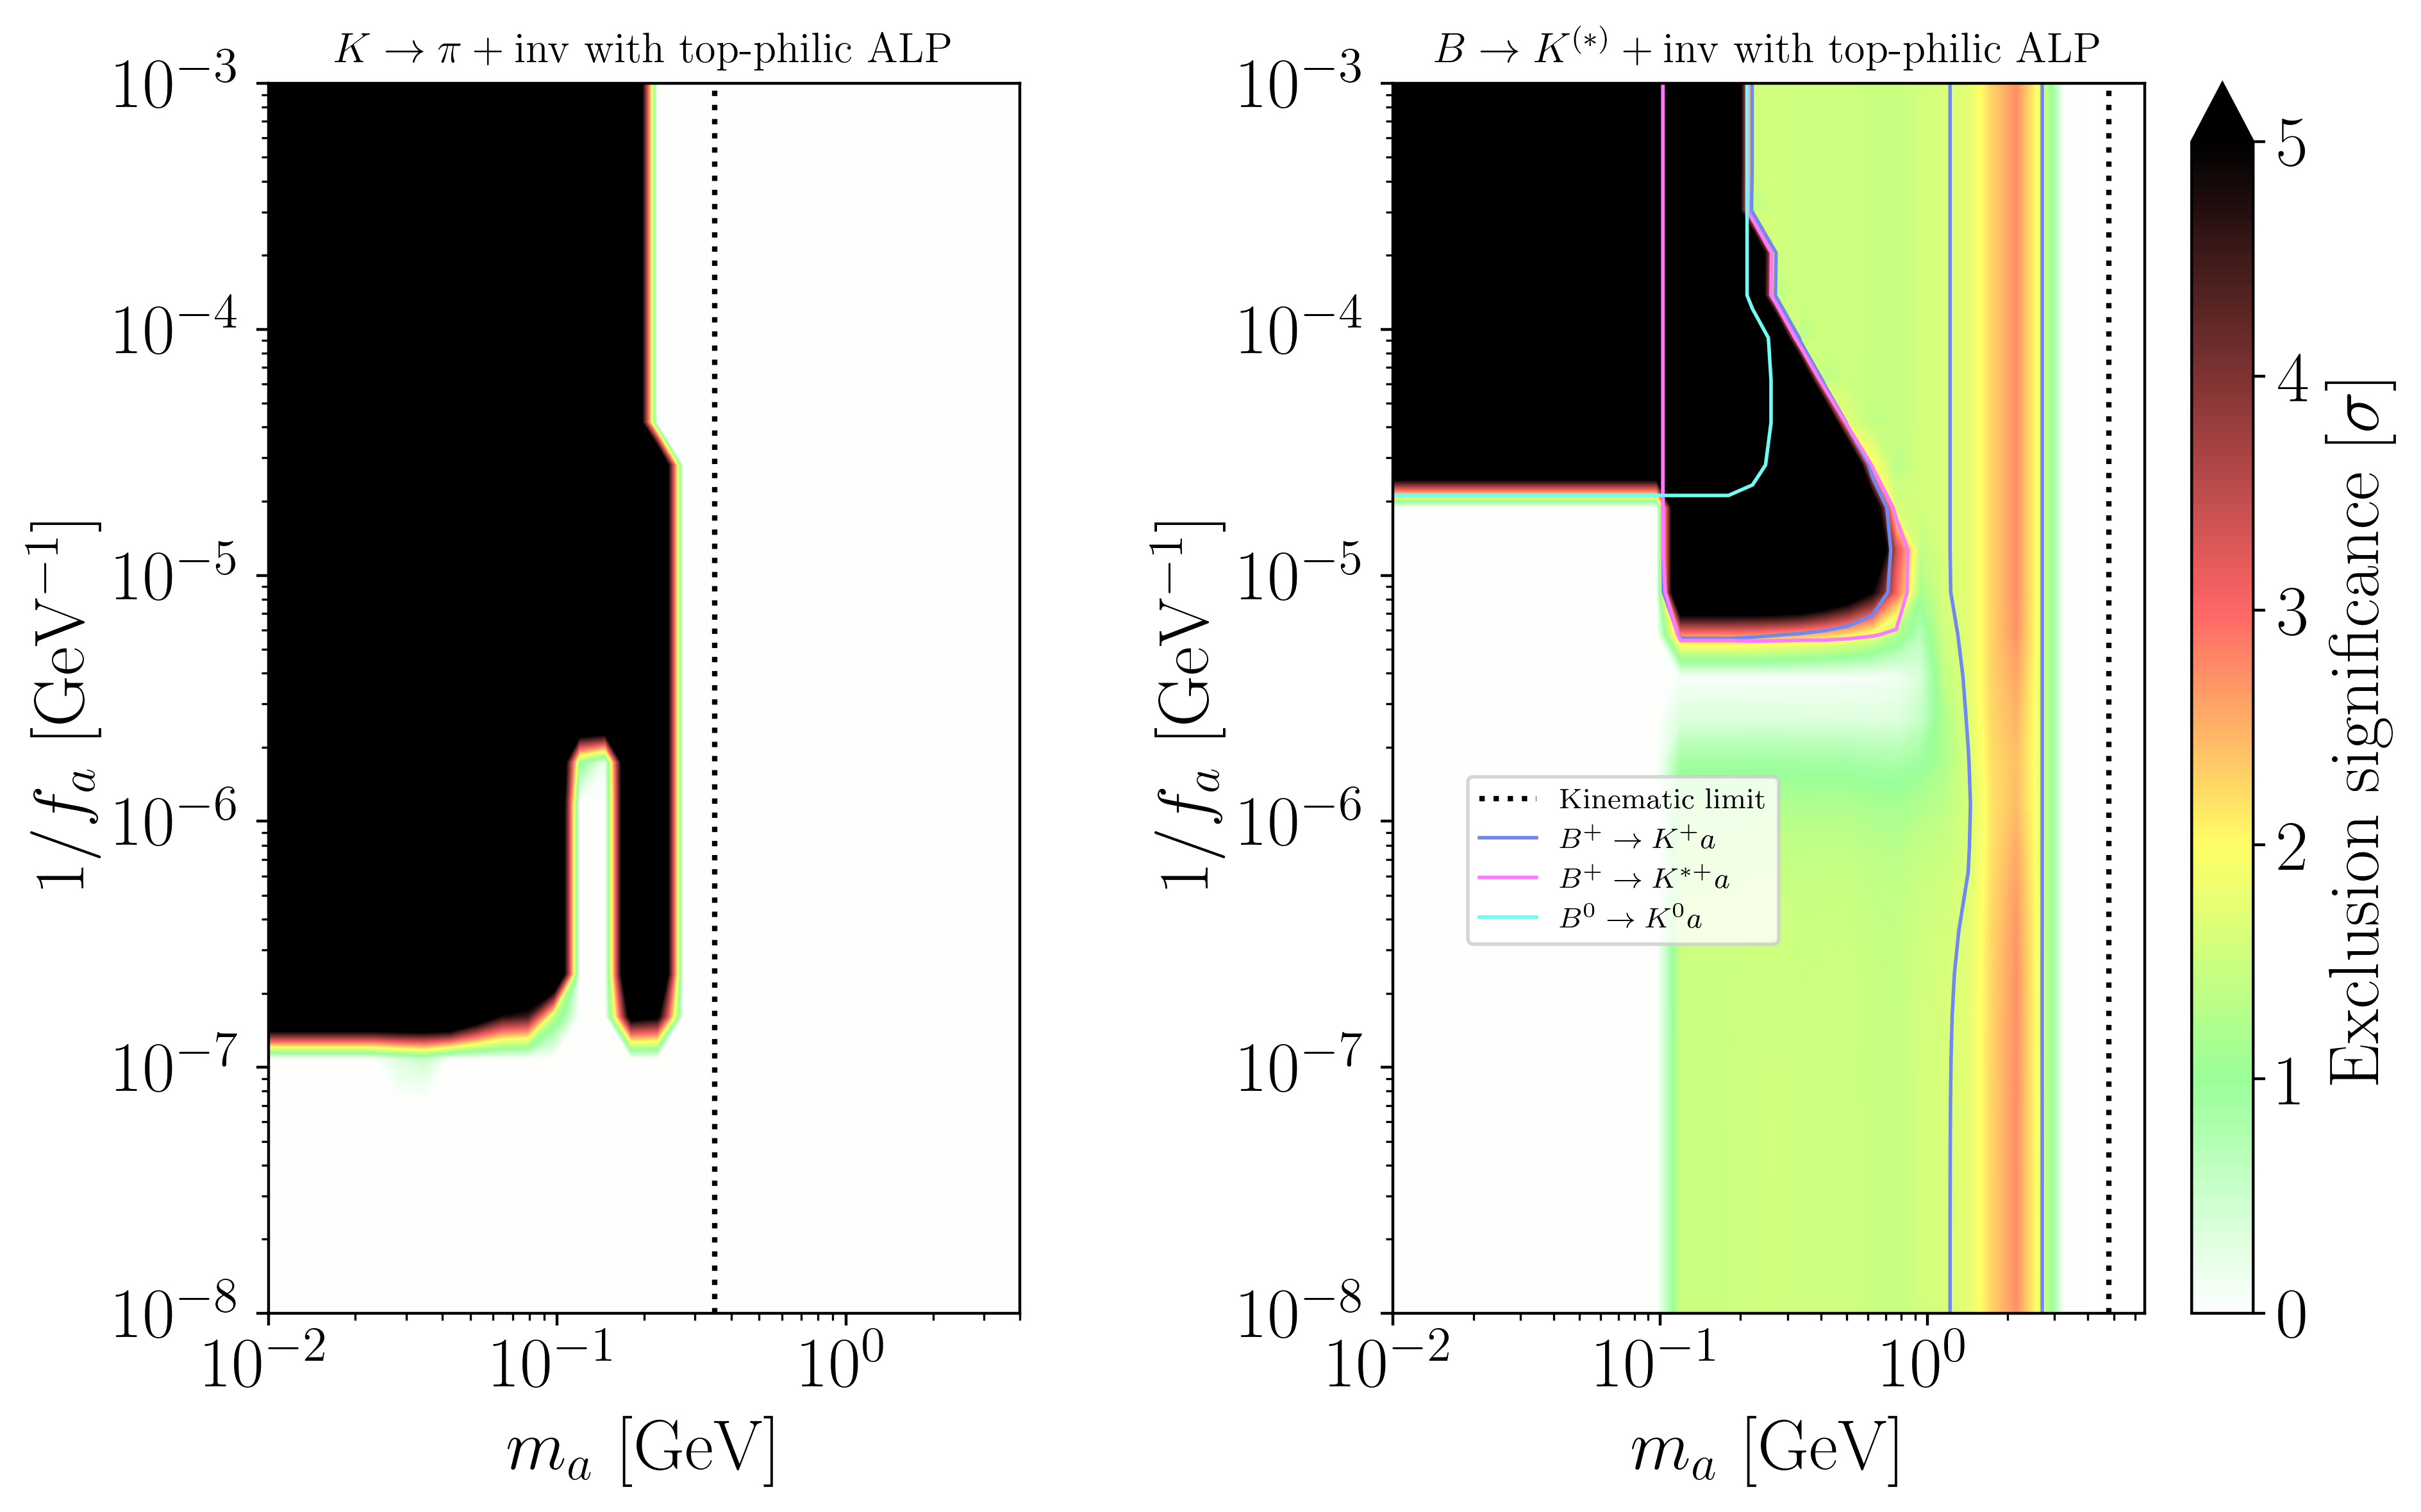

In [11]:
chi2_BKa = chi2[0].split_observables()

mB, mK, mpi = 5.28, 0.49, 0.139 # GeV

# Create subplots
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(25.4/2.54, 16/2.54),\
dpi=400)

# Plot a line in the 1st subplot
# BEFORE creating the exclusionplot
axs[0].axvline(mK - mpi, c='k', ls=':', label = 'Kinematic limit')
exclusionplot(
    x_ma, 1/y_fa, chi2[1],
    r'$m_a$ [GeV]', r'$1/f_a$ [GeV$^{-1}]$',
    r'$K\to \pi+\mathrm{inv}$ with top-philic ALP',
    ax=axs[0], # This goes to 1st subplot
)
# Remove the legend of the 1st subplot
legend0 = axs[0].get_legend()
legend0.remove()

# Plot a line in the 2nd subplot
# BEFORE creating the exclusionplot
axs[1].axvline(mB - mK, c='k', ls=':', label = 'Kinematic limit')
exclusionplot(
    x_ma, 1/y_fa, chi2_BKa,
    r'$m_a$ [GeV]', r'$1/f_a$ [GeV$^{-1}]$',
    r'$B\to K^{(*)} +\mathrm{inv}$ with top-philic ALP',
    ax=axs[1] # This goes to 2nd subplot
)
# Get legend of 2nd subplot
legend1 = axs[1].get_legend()
# We will reposition the lower left corner of the legend
legend1.set_loc('lower left')
# Reference point at x=0.1*plot_width
# and y=0.3*plot_height
# from lower left corner of the plot
legend1.set_bbox_to_anchor((0.1,0.3))
# Remove padding between legend and reference point
legend1.borderaxespad = 0

# Removing the colorbar of the first plot
# Each colorbar has its own axis,
# typically at the end of fig.axes
fig.axes[2].remove()
# Optimize blank spaces
fig.tight_layout()
fig.savefig('08_results/plot_customized.pdf', bbox_inches='tight')